## 1. Import Libraries

In [38]:
import os, random, string, pickle
from difflib import get_close_matches

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense,
    TimeDistributed, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from wordfreq import top_n_list

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## 2. Configuration
All hyper-parameters in one place.

In [39]:
# ── Special tokens ──────────────────────────────────────────────────
PAD_TOKEN = '<PAD>'   # index 0  – pad shorter sequences
SOS_TOKEN = '<SOS>'   # index 1  – start of sequence marker
EOS_TOKEN = '<EOS>'   # index 2  – end of sequence marker

# ── Sequence length ───────────────────────────────────────────────────
# MAX_LEN = SOS(1) + word_chars + EOS(1) + optional_padding
# 18 supports words up to 16 characters (covers >99 % of common English)
MAX_LEN = 18

# ── Model hyper-parameters ───────────────────────────────────────────
EMBED_DIM   = 64
LSTM_UNITS  = 128

# ── Training ──────────────────────────────────────────────────────────
DATASET_SIZE = 100_000
BATCH_SIZE   = 256
MAX_EPOCHS   = 50

print('MAX_LEN     :', MAX_LEN, ' → supports words up to', MAX_LEN - 2, 'characters')
print('EMBED_DIM   :', EMBED_DIM)
print('LSTM_UNITS  :', LSTM_UNITS)
print('DATASET_SIZE:', DATASET_SIZE)

MAX_LEN     : 18  → supports words up to 16 characters
EMBED_DIM   : 64
LSTM_UNITS  : 128
DATASET_SIZE: 100000


## 3. Build Vocabulary

The character vocabulary is: `<PAD>`, `<SOS>`, `<EOS>`, a-z, 0-9, `'`, `-`.

| Index | Token |
|---|---|
| 0 | `<PAD>` |
| 1 | `<SOS>` |
| 2 | `<EOS>` |
| 3 … | a-z, 0-9, `'`, `-` |

In [40]:
def build_vocab():
    """Return (char→idx, idx→char) dictionaries."""
    chars = list(string.ascii_lowercase + string.digits + "'-")
    vocab = {PAD_TOKEN: 0, SOS_TOKEN: 1, EOS_TOKEN: 2}
    for i, ch in enumerate(chars, start=3):
        vocab[ch] = i
    inv_vocab = {v: k for k, v in vocab.items()}
    return vocab, inv_vocab


# Build once; reuse everywhere
VOCAB, INV_VOCAB = build_vocab()
VOCAB_SIZE = len(VOCAB)

print(f'Vocabulary size : {VOCAB_SIZE}')
print('First 10 entries:', list(VOCAB.items())[:10])

Vocabulary size : 41
First 10 entries: [('<PAD>', 0), ('<SOS>', 1), ('<EOS>', 2), ('a', 3), ('b', 4), ('c', 5), ('d', 6), ('e', 7), ('f', 8), ('g', 9)]


## 4. Encoding & Decoding Functions

**`encode(word)`** → fixed-length integer list of length `MAX_LEN`  
**`decode_sequence(pred_probs)`** → string (ignores PAD/SOS, stops at EOS)

In [41]:
def encode(word, vocab=VOCAB, max_len=MAX_LEN):
    seq = [vocab[SOS_TOKEN]]
    seq += [vocab.get(ch.lower(), vocab[PAD_TOKEN]) for ch in word]
    seq += [vocab[EOS_TOKEN]]
    seq  = seq[:max_len]
    seq += [vocab[PAD_TOKEN]] * (max_len - len(seq))
    return seq


def decode_sequence(pred_probs, inv_vocab=INV_VOCAB, vocab=VOCAB,
                    max_output_len=None):          # ← NEW parameter
    """
    Convert model output to a string.
    Stops at EOS or PAD **and** when max_output_len characters collected.
    The length cap is the critical fix — the model does not reliably
    predict EOS/PAD at padding positions, so we must cut off ourselves.
    """
    result = []
    for step in pred_probs:
        idx   = int(np.argmax(step))
        token = inv_vocab.get(idx, '')

        # Hard stop conditions
        if token in (EOS_TOKEN, PAD_TOKEN, ''):
            break

        # Skip SOS
        if token == SOS_TOKEN:
            continue

        result.append(token)

        # Length cap — stop once we have enough characters          ← KEY FIX
        if max_output_len is not None and len(result) >= max_output_len:
            break

    return ''.join(result)


# Sanity check
sample_encoded = encode('hello')
one_hot = np.eye(VOCAB_SIZE)[sample_encoded]
sample_decoded = decode_sequence(one_hot, max_output_len=len('hello') + 3)
assert sample_decoded == 'hello', 'Encode/decode round-trip failed!'

## 5. Spelling-Mistake Generator

Five realistic error types:
1. **swap_adjacent** – transpose two neighbouring characters (`the → teh`)
2. **delete_char** – drop a random character (`environment → enviroment`)
3. **insert_char** – insert a random character (`copy → coppy`)
4. **replace_char** – replace with a keyboard-neighbour key
5. **double_char** – double a random character

In [42]:
# Keyboard neighbour map (QWERTY layout)
KEYBOARD_NEIGHBORS = {
    'a': 'sqwz',  'b': 'vghn',  'c': 'xdfv',  'd': 'srfce', 'e': 'wrsdf',
    'f': 'drtgv', 'g': 'ftyhb', 'h': 'gyujn', 'i': 'ujko',  'j': 'huikm',
    'k': 'jiol',  'l': 'kop',   'm': 'njk',   'n': 'bhjm',  'o': 'iklp',
    'p': 'ol',    'q': 'wa',    'r': 'edft',  's': 'awedxz','t': 'rfgy',
    'u': 'yhji',  'v': 'cfgb',  'w': 'qase',  'x': 'zsdc',  'y': 'tghu',
    'z': 'asx'
}

def swap_adjacent(word):
    """Swap two adjacent characters  e.g. 'the' → 'teh'"""
    if len(word) < 2: return word
    i = random.randint(0, len(word) - 2)
    lst = list(word)
    lst[i], lst[i + 1] = lst[i + 1], lst[i]
    return ''.join(lst)

def delete_char(word):
    """Remove a random character  e.g. 'environment' → 'enviroment'"""
    if len(word) < 2: return word
    i = random.randint(0, len(word) - 1)
    return word[:i] + word[i + 1:]

def insert_char(word):
    """Insert a random extra character  e.g. 'copy' → 'coppy'"""
    i  = random.randint(0, len(word))
    ch = random.choice(string.ascii_lowercase)
    return word[:i] + ch + word[i:]

def replace_char(word):
    """Replace a char with a keyboard-neighbour key"""
    if len(word) < 1: return word
    i        = random.randint(0, len(word) - 1)
    ch       = word[i].lower()
    neighbors = KEYBOARD_NEIGHBORS.get(ch, string.ascii_lowercase)
    return word[:i] + random.choice(neighbors) + word[i + 1:]

def double_char(word):
    """Double a random character  e.g. 'running' → 'runnning'"""
    if len(word) < 1: return word
    i = random.randint(0, len(word) - 1)
    return word[:i] + word[i] + word[i:]

MUTATIONS = [swap_adjacent, delete_char, insert_char, replace_char, double_char]

def introduce_mistake(word):
    """Apply 1 mutation (30 % chance of a second one) to *word*."""
    if len(word) < 3:
        return word
    mutated = random.choice(MUTATIONS)(word)
    if random.random() < 0.3:
        mutated = random.choice(MUTATIONS)(mutated)
    return mutated


# Demo
print('Mutation examples:')
for w in ['the', 'environment', 'computer', 'language', 'algorithm']:
    print(f'  {w:15s}  ->  {introduce_mistake(w)}')

Mutation examples:
  the              ->  thhee
  environment      ->  envirhoment
  computer         ->  computter
  language         ->  yanguage
  algorithm        ->  lagorithm


## 6. Common English Word List

We use the top-10 000 English words from **wordfreq** as our ground-truth vocabulary.  
Words longer than `MAX_LEN − 2` characters are excluded because they would be truncated during encoding.

In [43]:
RAW_WORDS  = top_n_list('en', 10_000)

# Keep only clean alphabetic words that fit inside MAX_LEN
BASE_WORDS = list({
    w.lower() for w in RAW_WORDS
    if len(w) >= 3
    and w.isalpha()
    and len(w) <= MAX_LEN - 2      # -2 accounts for SOS and EOS tokens
})

print(f'Total usable words : {len(BASE_WORDS)}')
print('Sample words       :', BASE_WORDS[:10])

Total usable words : 9601
Sample words       : ['ease', 'comprising', 'friends', 'integral', 'theatre', 'shanghai', 'unified', 'closure', 'lately', 'brother']


## 7. Generate Dataset & Prepare Arrays

70 % of samples are (noisy_word, clean_word) pairs;  
30 % are (clean_word, clean_word) so the model also learns to keep already-correct words unchanged.

In [44]:
def generate_dataset(n):
    """Return n (noisy, correct) string pairs."""
    pairs = []
    while len(pairs) < n:
        word = random.choice(BASE_WORDS)
        if random.random() < 0.7:
            noisy = introduce_mistake(word)
            pairs.append((noisy, word))
        else:
            pairs.append((word, word))
    return pairs


def prepare_data(pairs):
    """
    Convert string pairs to numpy arrays.
    X  shape: (N, MAX_LEN)      ← noisy encoded sequences
    y  shape: (N, MAX_LEN)      ← clean encoded sequences
    y must stay 2-D for sparse_categorical_crossentropy.
    """
    X = np.array([encode(noisy) for noisy, _     in pairs], dtype=np.int32)
    y = np.array([encode(clean) for _,     clean in pairs], dtype=np.int32)
    return X, y


print(f'Generating {DATASET_SIZE:,} pairs …', end=' ', flush=True)
pairs = generate_dataset(DATASET_SIZE)
print('done.')

X, y = prepare_data(pairs)

# y stays shape (N, MAX_LEN)  ← correct for sparse_categorical_crossentropy
print(f'X shape : {X.shape}   (input  – noisy words)')
print(f'y shape : {y.shape}   (target – clean words)')

print(f"\nExample pair: '{pairs[0][0]}'  →  '{pairs[0][1]}'")
print(f"  X[0] = {X[0]}")
print(f"  y[0] = {y[0]}")

Generating 100,000 pairs … done.
X shape : (100000, 18)   (input  – noisy words)
y shape : (100000, 18)   (target – clean words)

Example pair: 'atciively'  →  'actively'
  X[0] = [ 1  3 22  5 11 11 24  7 14 27  2  0  0  0  0  0  0  0]
  y[0] = [ 1  3  5 22 11 24  7 14 27  2  0  0  0  0  0  0  0  0]


## 8. Build the LSTM Model

```
Input  (MAX_LEN,)
  └─ Embedding  (vocab_size → embed_dim)   mask_zero=True
  └─ Bidirectional LSTM  (lstm_units)       return_sequences=True
  └─ Dropout  (0.20)
  └─ TimeDistributed Dense  (vocab_size, softmax)
Output (MAX_LEN, vocab_size)
```

**Loss**: `sparse_categorical_crossentropy`  
The target `y` is a 2-D integer array (not one-hot), which is exactly what this loss expects.

In [45]:
def build_model(vocab_size=VOCAB_SIZE, max_len=MAX_LEN,
                embed_dim=EMBED_DIM, lstm_units=LSTM_UNITS):
    model = Sequential([
        # Layer 1 – learn dense character representations
        # mask_zero=True tells all downstream layers to ignore PAD tokens
        Embedding(input_dim=vocab_size, output_dim=embed_dim,
                  input_length=max_len, mask_zero=True),

        # Layer 2 – Bidirectional LSTM: reads sequence both forwards & backwards
        # return_sequences=True passes a hidden state at EVERY time step
        Bidirectional(LSTM(lstm_units, return_sequences=True)),

        # Layer 3 – Dropout for regularisation (avoids overfitting)
        Dropout(0.20),

        # Layer 4 – Predict one character per time step
        TimeDistributed(Dense(vocab_size, activation='softmax'))
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_model()
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 9. Train the Model

Two callbacks:
- **EarlyStopping** – stops when `val_loss` stops improving (patience = 5)  
- **ReduceLROnPlateau** – halves the learning rate after 2 stagnant epochs

In [46]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

history = model.fit(
    X, y,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 55s 126ms/step - accuracy: 0.6409 - loss: 1.3229 - val_accuracy: 0.7152 - val_loss: 0.9138 - learning_rate: 0.0010
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 122ms/step - accuracy: 0.7248 - loss: 0.8691 - val_accuracy: 0.7401 - val_loss: 0.8072 - learning_rate: 0.0010
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 56s 159ms/step - accuracy: 0.7544 - loss: 0.7829 - val_accuracy: 0.7693 - val_loss: 0.7364 - learning_rate: 0.0010
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 56s 159ms/step - accuracy: 0.7750 - loss: 0.7314 - val_accuracy: 0.7832 - val_loss: 0.7004 - learning_rate: 0.0010
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 75s 139ms/step - accuracy: 0.7859 - loss: 0.6995 - val_accuracy: 0.7907 - val_loss: 0.6805 - learning_rate: 0.0010
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 55s 157ms/step - accuracy: 0.7943 - loss: 0.6763 - val_accuracy: 0.7948 - val_loss: 0.6669 - learning_rate: 0.0010
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 56s 159ms/step - accuracy: 0.8

## 10. Plot Training Curves

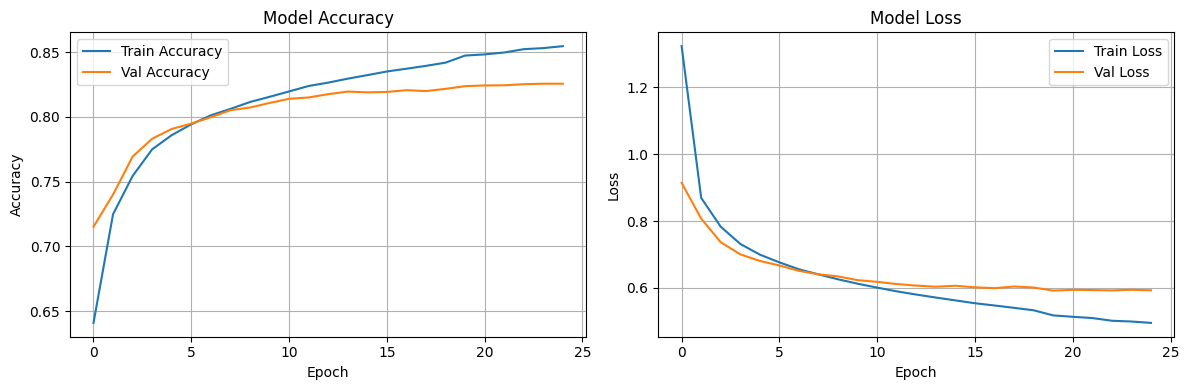

Plot saved as training_curves.png


In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True)

ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('Plot saved as training_curves.png')

## 11. Save Model & Vocabulary

Three files are saved:
| File | Contents |
|---|---|
| `autocorrect_model.keras` | Trained Keras model |
| `vocab.pkl` | `(VOCAB, INV_VOCAB)` dictionaries |
| `config.pkl` | `{max_len, vocab_size}` |

Load them later in a Streamlit app like this:
```python
from tensorflow.keras.models import load_model
model = load_model('autocorrect_model.keras')
with open('vocab.pkl','rb') as f: VOCAB, INV_VOCAB = pickle.load(f)
with open('config.pkl','rb') as f: cfg = pickle.load(f)
```

In [48]:
MODEL_PATH  = 'autocorrect_model.keras'
VOCAB_PATH  = 'vocab.pkl'
CONFIG_PATH = 'config.pkl'

# Native Keras format (recommended over legacy .h5)
model.save(MODEL_PATH)

with open(VOCAB_PATH, 'wb') as f:
    pickle.dump((VOCAB, INV_VOCAB), f)

with open(CONFIG_PATH, 'wb') as f:
    pickle.dump({'max_len': MAX_LEN, 'vocab_size': VOCAB_SIZE}, f)

print(f'Model saved  -> {MODEL_PATH}')
print(f'Vocab saved  -> {VOCAB_PATH}')
print(f'Config saved -> {CONFIG_PATH}')

Model saved  -> autocorrect_model.keras
Vocab saved  -> vocab.pkl
Config saved -> config.pkl


## 12. Prediction

**Two-stage correction:**
1. **LSTM stage** – the model outputs a character sequence.
2. **Dictionary snap** – `difflib.get_close_matches` maps that output to the nearest real word from `BASE_WORDS`.  

The dictionary snap acts as a guardrail so the final answer is always a known English word.

In [49]:
def dictionary_snap(word, wordlist=None):
    if wordlist is None:
        wordlist = BASE_WORDS
    matches = get_close_matches(word, wordlist, n=1, cutoff=0.6)
    return matches[0] if matches else word


def correct_word(text):
    tokens    = text.strip().lower().split()
    corrected = []

    for tok in tokens:
        x    = np.array([encode(tok)], dtype=np.int32)
        pred = model.predict(x, verbose=0)[0]

        # Cap output at input_length + 3
        # A correction is never dramatically longer than the original word.
        # This is the reliable stop condition when EOS/PAD aren't predicted.
        decoded = decode_sequence(pred, max_output_len=len(tok) + 3)  # ← KEY FIX

        base  = decoded if decoded else tok
        final = dictionary_snap(base)
        corrected.append(final)

    return ' '.join(corrected)

## 13. Test the Model on Common Misspellings

In [50]:
test_words = [
    'teh', 'enviroment', 'recieve', 'frend',
    'languge', 'comuter', 'databse', 'algorythm'
]

print(f"{'Misspelled':<20} {'Corrected'}")
print('-' * 40)
for w in test_words:
    print(f'{w:<20} {correct_word(w)}')

Misspelled           Corrected
----------------------------------------
teh                  tech
enviroment           environment
recieve              receive
frend                friend
languge              language
comuter              computer
databse              database
algorythm            algorithm


## 14. Try Your Own Word
Change `my_word` below and re-run this cell.

In [51]:
my_word = 'programing'

result = correct_word(my_word)
print(f'Input  : {my_word}')
print(f'Output : {result}')

Input  : programing
Output : programming
